### 3rd & 4th Exercise Notebook: Example Data Mining pipeline & Introduction to Sklearn 

#### About this Exercise
This is a comprehensive exercise that touches on a lot of the important steps in the data mining pipeline — from data preprocessing and feature engineering to model training and evaluation. It will give you hands-on experience applying the steps we've covered so far.

💡 Mastering this exercise will help you a lot in preparing for the final exam.

❗️Don't worry if you can't solve everything right away — data science is as much about iteration as it is about intuition. Take your time, stay curious, and most importantly: don’t give up.

🚫 Please avoid using ChatGPT or other AI assistants to solve the tasks. Solving the problems yourself will help you internalize the concepts more effectively.

### Context:
In the last sessions, you have learned to setup conda environment, program with numpy, and pandas. Now, it is time for more fun with a real data modelling pipeline.

Perhaps one of the most infamous shipwrecks in history, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 people on board. Interestingly, by analysing the probability of survival based on few attributes like gender, age, and social status, we can make very accurate predictions on which passengers would survive. Some groups of people were more likely to survive than others, such as women, children, and the upper-class. Therefore, we can learn about the society priorities and privileges at the time.

### VARIABLE DESCRIPTIONS
- Pclass Passenger Class (1 = 1'st; 2 = 2nd; 3 = 3rd)
- survival Survival (0 = No; 1 = Yes)
- name Name
- sex Sex
- age Age
- sibsp Number of Siblings/Spouses Aboard
- parch Number of Parents/Children Aboard
- ticket Ticket Number
- fare Passenger Fare (British pound)
- cabin Cabin
- embarked Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)
- boat Lifeboat
- body Body Identification Number
- home.dest Home/Destination

### Goal:
Build a modelling Pipeline, to engineer the features in the data set and predict who is more likely to Survive the catastrophe.

Follow the Jupyter notebook below, and solve the tasks marked as ✅ Task for students.

In [1]:
# to handle datasets
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt

# to visualise all the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)

In [2]:
# set the random seed to ensure reproducibility
random_seed = 0 

## Prepare the data set

In [3]:
# load the data - it is available open source and online
data = pd.read_csv('https://www.openml.org/data/get_csv/16826755/phpMYEkMl')
data.head()


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pclass     1309 non-null   int64 
 1   survived   1309 non-null   int64 
 2   name       1309 non-null   object
 3   sex        1309 non-null   object
 4   age        1309 non-null   object
 5   sibsp      1309 non-null   int64 
 6   parch      1309 non-null   int64 
 7   ticket     1309 non-null   object
 8   fare       1309 non-null   object
 9   cabin      1309 non-null   object
 10  embarked   1309 non-null   object
 11  boat       1309 non-null   object
 12  body       1309 non-null   object
 13  home.dest  1309 non-null   object
dtypes: int64(4), object(10)
memory usage: 143.3+ KB


In [5]:
# ✅ Task for students: check the percentage of NaN and the data type of each column
# add your code here
nulldata=data.isnull().mean()*100
print(nulldata)


pclass       0.0
survived     0.0
name         0.0
sex          0.0
age          0.0
sibsp        0.0
parch        0.0
ticket       0.0
fare         0.0
cabin        0.0
embarked     0.0
boat         0.0
body         0.0
home.dest    0.0
dtype: float64


In [6]:
# ✅ Task for students: replace question marks by NaN values, why?
# add your code here
data=data.replace('?', np.nan)
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,NaN,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [7]:
# ✅ Task for students: Loop through categorical columns and print the unqiue values of each categorical column
# add your code here
categorical_cols=data.select_dtypes(include=['object', 'category'])
for column in categorical_cols:
    print(categorical_cols[column].unique())
data.head()
    

['Allen, Miss. Elisabeth Walton' 'Allison, Master. Hudson Trevor'
 'Allison, Miss. Helen Loraine' ... 'Zakarian, Mr. Mapriededer'
 'Zakarian, Mr. Ortin' 'Zimmerman, Mr. Leo']
['female' 'male']
['29' '0.9167' '2' '30' '25' '48' '63' '39' '53' '71' '47' '18' '24' '26'
 '80' nan '50' '32' '36' '37' '42' '19' '35' '28' '45' '40' '58' '22' '41'
 '44' '59' '60' '33' '17' '11' '14' '49' '76' '46' '27' '64' '55' '70'
 '38' '51' '31' '4' '54' '23' '43' '52' '16' '32.5' '21' '15' '65' '28.5'
 '45.5' '56' '13' '61' '34' '6' '57' '62' '67' '1' '12' '20' '0.8333' '8'
 '0.6667' '7' '3' '36.5' '18.5' '5' '66' '9' '0.75' '70.5' '22.5' '0.3333'
 '0.1667' '40.5' '10' '23.5' '34.5' '20.5' '30.5' '55.5' '38.5' '14.5'
 '24.5' '60.5' '74' '0.4167' '11.5' '26.5']
['24160' '113781' '19952' '13502' '112050' '11769' 'PC 17609' 'PC 17757'
 'PC 17477' '19877' '27042' 'PC 17318' 'PC 17558' '11813' '13050' '11751'
 '111369' 'PC 17483' '13905' '11967' 'PC 17760' '110564' '113784' '112277'
 '36928' '113783' '110489' 

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,NaN,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [8]:
# ✅ Task for students: retain only the first cabin if more than 1 are available per passenger
# add your code here
data["cabin"]=data["cabin"].str.split().str[0]
print(data["cabin"])
print(data.columns)


0        B5
1       C22
2       C22
3       C22
4       C22
       ... 
1304    NaN
1305    NaN
1306    NaN
1307    NaN
1308    NaN
Name: cabin, Length: 1309, dtype: object
Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')


In [9]:
# ✅ Task for students: extracts the title (Mr, Ms, etc) from the name variable
# add your code here
# Añadimos .str.strip() para quitar el espacio inicial que queda después de la coma
print(data.columns.tolist())
data["title"] = data["name"].str.split(',').str[1].str.split('.').str[0].str.strip()
print(data["title"])   

['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']
0         Miss
1       Master
2         Miss
3           Mr
4          Mrs
         ...  
1304      Miss
1305      Miss
1306        Mr
1307        Mr
1308        Mr
Name: title, Length: 1309, dtype: object


In [10]:
# ✅ Task for students: cast numerical variables as floats (age and fare)
# add your code here
data["age"]=data["age"].astype(float)
data["fare"]=data["fare"].astype(float)



In [11]:
# ✅ Task for students: which of these columns would you consider for one-hot encoding? and which ones are useless for the analysis? 
# add your code here
one_hot_encoding=["cabin, embarked, pclass, sex"]
not_useful=["name", "ticket", "home.dest"]
# Ticket and name are not useful for the analysis as they are unique for each passgener and dont have any effect on the target variable.

In [12]:
# ✅ Task for students: drop unnecessary variables 
data=data.drop(columns=not_useful)
data.head()
# add your code here


,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked,boat,body,title
0,1,1,female,29.0000,0,0,211.3375,B5,S,2,NaN,Miss
1,1,1,male,0.9167,1,2,151.5500,C22,S,11,NaN,Master
2,1,0,female,2.0000,1,2,151.5500,C22,S,NaN,NaN,Miss
3,1,0,male,30.0000,1,2,151.5500,C22,S,NaN,135,Mr
4,1,0,female,25.0000,1,2,151.5500,C22,S,NaN,NaN,Mrs


In [13]:
# ✅ Task for students: save the data set into a titanic.csv file 
# add your code here
data.to_csv('titanic.csv', index=False)

## Data Exploration

#### In the processed data, find numerical and categorical variables

In [14]:
target = 'survived' # the target we are predicting

# categorical variables
vars_num = [c for c in data.columns if data[c].dtypes!='O' and c!=target]
print('Number of numerical variables: {}'.format(len(vars_num)))

Number of numerical variables: 5


#### ✅ Task for students: find numerical and categorical variables in the processed data

In [15]:
# add your code here
cat_cols=[]
for column in data:
    if data[column].dtype=='O' and column!=target:
        cat_cols.append(column)
cat_cols
print(len(cat_cols))

6


#### Find percentages of missing values in the variables

In [16]:
# first in numerical variables
print(data[vars_num].isnull().mean()*100)

pclass     0.000000
age       20.091673
sibsp      0.000000
parch      0.000000
fare       0.076394
dtype: float64


#### ✅ Task for students:  Find percentages of missing values in categorical variables

In [17]:
# add your code here
print(data[cat_cols].isnull().mean()*100)

sex          0.000000
cabin       77.463713
embarked     0.152788
boat        62.872422
body        90.756303
title        0.000000
dtype: float64


#### ✅ Task for students: Determine cardinality of categorical variables

In [18]:
# add your code here
cardinality=[]
for cols in cat_cols:
    cardinality.append(data[cols].nunique())
print(cardinality)

[2, 181, 3, 27, 121, 18]


#### ✅ Task for students plot the distribution of numerical variables

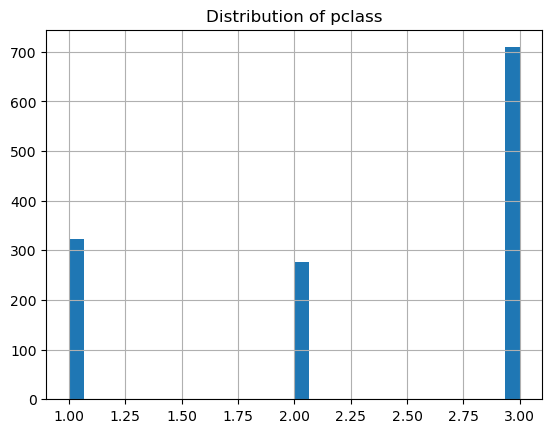

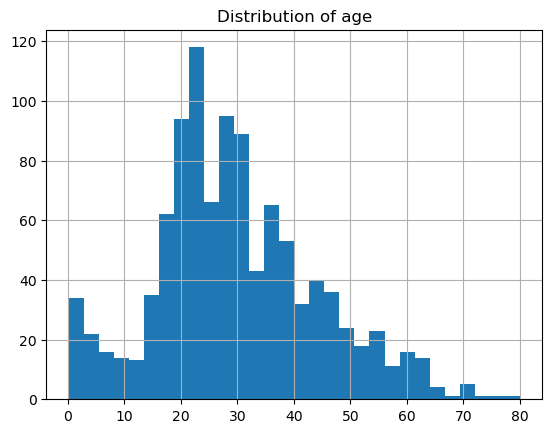

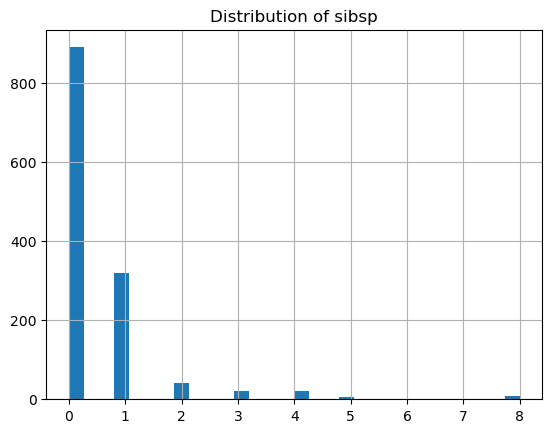

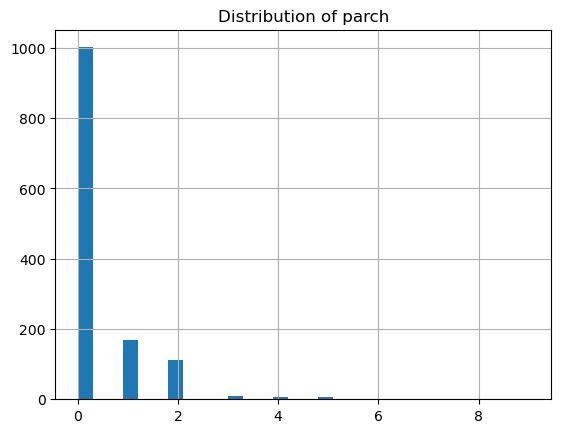

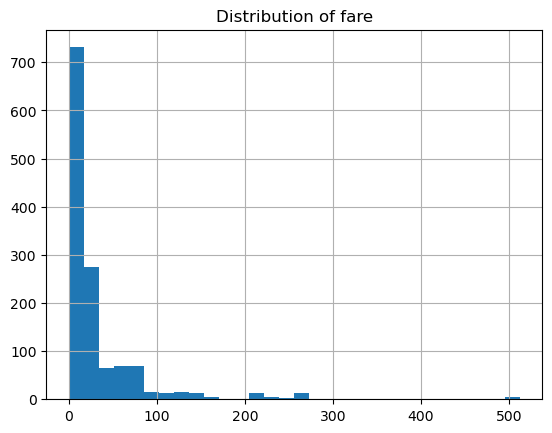

In [19]:
# add your code here
for col in vars_num:
    data[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

#### ✅ Task for students: Separate data into train and test
use train_test_split from sklearn to divide train and test set, use 0.2 test and the remaining as train

In [20]:
from sklearn.model_selection import train_test_split as tts
# add your code here
X_train_data, X_test_data=tts(data, train_size=0.8, random_state=42)


### Feature Engineering

#### ✅ Task for students: Extract only the letter (and drop the number) from the variable Cabin

In [21]:
# add your code here
X_train_data["cabin"]=X_train_data["cabin"].str[0]
X_test_data["cabin"]=X_test_data["cabin"].str[0]
X_train_data.head()


,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked,boat,body,title
772,3,0,male,17.0,0,0,7.8958,NaN,S,NaN,NaN,Mr
543,2,0,male,36.0,0,0,10.5000,NaN,S,NaN,NaN,Mr
289,1,1,female,18.0,0,2,79.6500,E,S,8,NaN,Miss
10,1,0,male,47.0,1,0,227.5250,C,C,NaN,124,Col
147,1,0,male,NaN,0,0,42.4000,NaN,S,NaN,NaN,Mr


#### Fill in Missing data in numerical variables:

- Add a binary missing indicator
- Fill NA in original variable with the median

In [22]:
# add missing indicator for age variable
X_train_data["age_missing"]=X_train_data["age"].isna().astype(int)

X_train_data.head()

,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked,boat,body,title,age_missing
772,3,0,male,17.0,0,0,7.8958,NaN,S,NaN,NaN,Mr,0
543,2,0,male,36.0,0,0,10.5000,NaN,S,NaN,NaN,Mr,0
289,1,1,female,18.0,0,2,79.6500,E,S,8,NaN,Miss,0
10,1,0,male,47.0,1,0,227.5250,C,C,NaN,124,Col,0
147,1,0,male,NaN,0,0,42.4000,NaN,S,NaN,NaN,Mr,1


In [23]:
# replace NaN by median you extracted from the training data
X_train_data["age"]=X_train_data["age"].fillna(X_train_data["age"].median())
X_test_data["age"]=X_test_data["age"].fillna(X_test_data["age"].median())
X_test_data.head()

,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked,boat,body,title
1148,3,0,male,35.0,0,0,7.1250,NaN,S,NaN,NaN,Mr
1049,3,1,male,20.0,1,1,15.7417,NaN,C,C,NaN,Mr
982,3,0,male,29.0,0,0,7.8958,NaN,S,NaN,NaN,Mr
808,3,0,male,29.0,0,0,8.0500,NaN,S,NaN,NaN,Mr
1195,3,0,male,29.0,0,0,7.7500,NaN,Q,NaN,NaN,Mr


#### ✅ Task for students: add missing indicator for fare variable

In [24]:
# add your code here
X_train_data["fare_missing"]=X_train_data["fare"].isna().astype(int)

#### ✅ Task for students: replace NaN by median you extracted from the training data

In [25]:
# add your code here
X_train_data["fare"]=X_train_data["fare"].fillna(X_train_data["fare"].mean())
X_test_data["fare"]=X_test_data["fare"].fillna(X_test_data["fare"].mean())

In [26]:
# check if the missing values were correctly replaced
X_train_data["age"].isna().sum()

np.int64(0)

#### ✅ Task for students: Replace Missing data in categorical variables with the string **Missing**

In [27]:
# add your code here
if X_train_data[cat_cols].isna().sum().sum()>0:
    X_train_data[cat_cols].fillna("Missing")
X_train_data[cat_cols].head(20)


,sex,cabin,embarked,boat,body,title
772,male,NaN,S,NaN,NaN,Mr
543,male,NaN,S,NaN,NaN,Mr
289,female,E,S,8,NaN,Miss
10,male,C,C,NaN,124,Col
147,male,NaN,S,NaN,NaN,Mr
348,male,NaN,S,NaN,NaN,Mr
983,male,NaN,S,NaN,NaN,Mr
825,male,NaN,S,NaN,NaN,Master
350,female,NaN,S,14,NaN,Miss
900,male,NaN,S,NaN,NaN,Master


check is there are any missing data in any of the variables in both test and train

In [28]:
X_train_data.isna().sum()


pclass            0
survived          0
sex               0
age               0
sibsp             0
parch             0
fare              0
cabin           813
embarked          1
boat            672
body            948
title             0
age_missing       0
fare_missing      0
dtype: int64

In [29]:
X_test_data.isna().sum()

pclass        0
survived      0
sex           0
age           0
sibsp         0
parch         0
fare          0
cabin       201
embarked      1
boat        151
body        240
title         0
dtype: int64

#### ✅ Task for students: Remove rare labels in categorical variables
- print the different value counts for each of the categories in the cabin variable, what do you notice
- use the df[column].value_counts(normalize=True) to find the percentage of each category for each variable
- remove labels present in less than 5 % of the passengers

In [30]:
# add your code here
X_train_data["cabin"].nunique()
X_train_data["cabin"].value_counts(normalize=True)
X_train_data= X_train_data[~X_train_data["cabin"].isin(["T", "G"])]
print(X_train_data["cabin"].unique())
X_test_data["cabin"].value_counts(normalize=True)


[nan 'E' 'C' 'B' 'A' 'F' 'D']


cabin
C    0.311475
E    0.245902
B    0.213115
D    0.081967
A    0.081967
F    0.065574
Name: proportion, dtype: float64

In [31]:
# print the cardinality of categorical variables
X_train_data[cat_cols].nunique()

sex          2
cabin        6
embarked     3
boat        25
body        99
title       16
dtype: int64

In [32]:
# print the cardinality of categorical variables
X_train_data[vars_num].nunique()

pclass      3
age        94
sibsp       7
parch       8
fare      261
dtype: int64

####  ✅ Task for students: Perform one hot encoding of categorical variables into k-1 binary variables

- k-1, means that if the variable contains 9 different categories, we create 8 different binary variables
- use OneHotEncoder from sklearn. The encoder will output a numpy array. You should use encoder.get_feature_names_out() to recreate a new dataframe
- remember to fit the encoder to the training data and to use it on the test data
- Remember to drop the original categorical variable (the one with the strings) after the encoding

In [33]:
from sklearn.preprocessing import OneHotEncoder 
# add your code here
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded_array=encoder.fit_transform(X_train_data[cat_cols])
encoded_cols=encoder.get_feature_names_out(cat_cols)
new_X_train_data=pd.DataFrame(encoded_array, columns=encoded_cols, index=X_train_data.index)
X_train_data=pd.concat([X_train_data[vars_num], new_X_train_data],axis=1)

testencoded_array=encoder.transform(X_test_data[cat_cols])
newX_test_data=pd.DataFrame(testencoded_array, columns=encoded_cols, index=X_test_data.index)
X_test_data= pd.concat([X_test_data[vars_num],newX_test_data], axis=1)

/Users/mortega/miniconda3/envs/DataMining/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [34]:
# make sure both dataframes have the same columns with the same order (important for scaling)
X_test_data.head(20)

,pclass,age,sibsp,parch,fare,sex_male,cabin_B,cabin_C,cabin_D,cabin_E,cabin_F,cabin_nan,embarked_Q,embarked_S,embarked_nan,boat_10,boat_11,boat_12,boat_13,boat_13 15,boat_14,boat_15,boat_15 16,boat_16,boat_2,boat_3,boat_4,boat_5,boat_5 7,boat_6,boat_7,boat_8,boat_8 10,boat_9,boat_A,boat_B,boat_C,boat_C D,boat_D,boat_nan,body_101,body_103,body_108,body_109,body_110,body_119,body_120,body_121,body_122,body_124,body_126,body_131,body_135,body_14,body_143,body_147,body_148,body_149,body_15,body_155,body_156,body_165,body_166,body_169,body_17,body_172,body_174,body_175,body_176,body_18,body_181,body_187,body_188,body_189,body_19,body_190,body_196,body_197,body_201,body_206,body_207,body_208,body_209,body_22,body_230,body_232,body_245,body_249,body_255,body_256,body_259,body_260,body_261,body_263,body_271,body_283,body_284,body_285,body_286,body_287,body_292,body_294,body_295,body_297,body_299,body_304,body_305,body_306,body_307,body_309,body_314,body_32,body_322,body_327,body_328,body_37,body_38,body_4,body_43,body_45,body_46,body_47,body_51,body_53,body_58,body_61,body_62,body_67,body_68,body_7,body_72,body_75,body_80,body_89,body_9,body_96,body_97,body_98,body_nan,title_Don,title_Dr,title_Jonkheer,title_Lady,title_Major,title_Master,title_Miss,title_Mlle,title_Mme,title_Mr,title_Mrs,title_Ms,title_Rev,title_Sir,title_the Countess
1148,3,35.0,0,0,7.1250,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1049,3,20.0,1,1,15.7417,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
982,3,29.0,0,0,7.8958,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
808,3,29.0,0,0,8.0500,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1195,3,29.0,0,0,7.7500,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0

#### ✅ Task for students: Scale the variables
-  Use the standard scaler from Scikit-learn
-  make sure that you have the same order of variables in both train and test data
-  dont forget to use the same scaling parameters from the train data for the test data

In [ ]:
# feature scaling
from sklearn.preprocessing import StandardScaler
# add your code here
scaler=StandardScaler()
X_train_data=scaler.fit_transform(X_train_data)
X_test_data=scaler.transform(X_test_data)

#### ✅ Task for students: Train a Logistic Regression model from sklearn

- use sklearn to build a LogisticRegression model
- Set the regularization parameter to 0.0005
- Set the seed to 0 for reproducibility
- remember to train the model by using model.fit after you initialize it

In [ ]:
# import the model
from sklearn.linear_model import LogisticRegression
# add your code here
model=LogisticRegression()
model.fit(X_train_data, Y_train_data)

### Make predictions and evaluate model performance
Determine:
- accuracy
- roc-auc
on both training and test data. Try different options (weighted vs. micro vs. macro) and try to understand the differences

**Important, remember that to determine the accuracy, you need the outcome 0, 1, referring to survived or not. But to determine the roc-auc you need the probability of survival.**

In [37]:
# to evaluate the models 
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score


# make predictions for train set
class_ = model.predict(X_train)
pred = model.predict_proba(X_train)[:,1]

# determine roc-auc and accuracy
print('train roc-auc: {}'.format(roc_auc_score(y_train, pred)))
print('train accuracy: {}'.format(accuracy_score(y_train, class_)))

print()

NameError: name 'model' is not defined

#### ✅ Task for students: make predictions for test set and print accuracy and roc-auc


In [ ]:
# add your code here


### That's it! Well done